# Mini-Project 4: Rainfall Pattern & Crop Suitability Analyser

**The scenario.** An agricultural extension officer wants to compare rainfall
regimes across three regions and advise farmers on which months suit which
crops.

**The data.** Monthly rainfall in mm for Kampala, Gulu and Mbarara, as given
in the brief. The figures are *illustrative*.

**What is being corrected.** The previous version asked for "cosine
similarity" using `math.cos()`, which returns the cosine of a single angle in
radians and says nothing whatever about how two rainfall profiles relate. The
real measure is implemented here and checked against SciPy.

**Where the code lives.** `src/rainfall.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.spatial.distance import cosine as scipy_cosine

from src.charts import DATA, SERIES_COLOURS, store, use_house_style
from src.rainfall import (
    CROPS, DRY, FINE, MONTHS, WET, CropCalendar, Region, RegionComparison,
    SeasonDetector, cosine_similarity, euclidean_distance, load_power_csv,
    load_regions, pearson_correlation)

use_house_style()
SEED = 1234
pd.set_option("display.float_format", "{:,.3f}".format)

regions = load_regions()
print("regions:", ", ".join(r.name for r in regions))

regions: Kampala, Gulu, Mbarara


## Task 1: the `Region` class

In [2]:
for region in regions:
    print(repr(region))

pd.DataFrame([r.profile() for r in regions], index=[r.name for r in regions])

<Region Kampala: 1,600 mm/yr, wettest May, driest Sep>
<Region Gulu: 1,388 mm/yr, wettest Aug, driest Jan>
<Region Mbarara: 1,040 mm/yr, wettest Apr, driest Jul>


,annual_mm,mean_mm,sd_mm,wettest,driest,cv
Kampala,"1,600.000",133.333,51.757,May,Sep,0.388
Gulu,"1,388.000",115.667,74.204,Aug,Jan,0.642
Mbarara,"1,040.000",86.667,38.455,Apr,Jul,0.444


The coefficient of variation is the column that matters. Gulu's 0.64 says the
rain arrives in one concentrated season with an almost dry start to the year
— January delivers 8 mm. Kampala's 0.39 says it is spread far more evenly.
That distinction drives planting advice, and it is invisible in the annual
totals: Gulu and Kampala differ by only about 210 mm a year.

In [3]:
pd.DataFrame({r.name: r.rainfall for r in regions}, index=list(MONTHS)).T

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Kampala,120.000,140.000,180.000,200.000,220.000,180.000,90.000,70.000,60.000,100.000,110.000,130.000
Gulu,8.000,25.000,75.000,160.000,190.000,145.000,170.000,215.000,175.000,150.000,60.000,15.000
Mbarara,70.000,85.000,120.000,140.000,90.000,25.000,20.000,55.000,100.000,125.000,120.000,90.000


## Task 2: crop rules with cited thresholds

The bands come from FAO crop *water needs* over a full growing period: the
lower bound is the smallest seasonal requirement divided by the longest
growing period, the upper bound the largest requirement divided by the
shortest. The result is the monthly rate at which a crop meets its seasonal
need.

The three crops are the staple, the wetland cereal and the main rotation
legume of Uganda's central and eastern farming systems — which is where the
advisory note at the end is directed.

In [4]:
for rule in CROPS:
    print(f"{str(rule):<32} {rule.citation}")

Banana (100-220 mm/month)        FAO (1986) Irrigation Water Management Training Manual No. 3: Irrigation Water Needs, Brouwer & Heibloem, Table 4: 1,200-2,200 mm over 300-365 days
Paddy rice (90-233 mm/month)     FAO (1986) Irrigation Water Management Training Manual No. 3: Irrigation Water Needs, Brouwer & Heibloem, Table 4: 450-700 mm over 90-150 days
Soybean (92-159 mm/month)        FAO (1986) Irrigation Water Management Training Manual No. 3: Irrigation Water Needs, Brouwer & Heibloem, Table 4: 450-700 mm over 135-150 days


In [5]:
calendar = CropCalendar(regions, CROPS)
print(repr(calendar))
print("\nmonths classified 'good', by crop and region:")
calendar.summary()

CropCalendar(regions=['Kampala', 'Gulu', 'Mbarara'], crops=['Banana', 'Paddy rice', 'Soybean'])

months classified 'good', by crop and region:


,Banana,Paddy rice,Soybean
Kampala,9,10,5
Gulu,7,7,2
Mbarara,5,7,5


In [6]:
calendar.verdicts("Banana")

,Kampala,Gulu,Mbarara
Jan,good,drought risk,drought risk
Feb,good,drought risk,drought risk
Mar,good,drought risk,good
Apr,good,good,good
May,good,good,drought risk
Jun,good,good,drought risk
Jul,drought risk,good,drought risk
Aug,drought risk,good,drought risk
Sep,drought risk,good,good
Oct,good,good,good


**A pattern worth naming.** Soybean suits far fewer months than banana or
rice in every region, and the reason is the width of its band, not its
thirst. All three crops need roughly the same amount of rain *per month*
(90-100 mm at the bottom), because a crop with a smaller seasonal requirement
usually has a shorter growing period too, and the two effects cancel. What
separates them is the ceiling: soybean tolerates 159 mm a month, rice 233 mm.
So the classification here is driven almost entirely by waterlogging risk
rather than by drought.

## Task 3: cosine similarity, implemented correctly

$$\cos\theta = \frac{\mathbf{a}\cdot\mathbf{b}}
{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert}$$

— the normalised dot product of two vectors, which has nothing to do with
`math.cos`.

In [7]:
print("what the old method actually computed:")
print(f"  math.cos(220) = {np.cos(220):.6f}   <- the cosine of 220 radians")
print("  ...a number about an angle, not about two rainfall profiles.\n")

comparison = RegionComparison(regions)
print("checked against scipy.spatial.distance.cosine (similarity = 1 - distance):")
comparison.cross_check()

what the old method actually computed:
  math.cos(220) = 0.996085   <- the cosine of 220 radians
  ...a number about an angle, not about two rainfall profiles.

checked against scipy.spatial.distance.cosine (similarity = 1 - distance):


,ours,scipy,difference
pair,,,
Kampala / Gulu,0.787,0.787,0.000
Kampala / Mbarara,0.891,0.891,0.000
Gulu / Mbarara,0.749,0.749,0.000


In [8]:
a, b = regions[0], regions[1]
by_hand = float(np.dot(a.rainfall, b.rainfall)
                / (np.linalg.norm(a.rainfall) * np.linalg.norm(b.rainfall)))
assert np.isclose(by_hand, cosine_similarity(a.rainfall, b.rainfall))
assert np.isclose(by_hand, 1 - scipy_cosine(a.rainfall, b.rainfall))
print(f"dot / (|a| |b|), by hand            = {by_hand:.10f}")
print(f"cosine_similarity()                 = "
      f"{cosine_similarity(a.rainfall, b.rainfall):.10f}")
print(f"1 - scipy.spatial.distance.cosine() = "
      f"{1 - scipy_cosine(a.rainfall, b.rainfall):.10f}")
print("\n[checked] all three agree to machine precision")

dot / (|a| |b|), by hand            = 0.7866089875
cosine_similarity()                 = 0.7866089875
1 - scipy.spatial.distance.cosine() = 0.7866089875

[checked] all three agree to machine precision


## Task 4: three measures, three different questions

In [9]:
for name, matrix in comparison.every_matrix().items():
    print(f"\n{name}")
    print(matrix.round(4).to_string())


cosine
         Kampala  Gulu  Mbarara
Kampala    1.000 0.787    0.891
Gulu       0.787 1.000    0.749
Mbarara    0.891 0.749    1.000

pearson
         Kampala   Gulu  Mbarara
Kampala    1.000 -0.066    0.209
Gulu      -0.066  1.000   -0.174
Mbarara    0.209 -0.174    1.000

euclidean
         Kampala    Gulu  Mbarara
Kampala    0.000 315.268  250.400
Gulu     315.268   0.000  312.800
Mbarara  250.400 312.800    0.000


In [10]:
comparison.pairs()

,cosine,pearson,euclidean_mm,annual_gap_mm
pair,,,,
Kampala / Gulu,0.787,-0.066,315.268,212.000
Kampala / Mbarara,0.891,0.209,250.400,560.000
Gulu / Mbarara,0.749,-0.174,312.800,348.000


**Why cosine calls two regions similar when one is much wetter.** Cosine
similarity measures the angle between two vectors and throws their lengths
away: multiplying a profile by any positive constant leaves it untouched.
Rainfall is non-negative, so every one of these vectors lies in the positive
orthant, where no two vectors can be more than 90° apart and the cosine
therefore cannot go below zero. In twelve dimensions, two arbitrary positive
vectors are typically 0.7-0.9 similar before any genuine resemblance enters
into it. That is exactly what we see: every pair scores between 0.75 and
0.89, which looks like strong agreement and is really the floor imposed by
the data being positive.

Pearson correlation subtracts the means first, so it asks the question an
extension officer actually needs answered — *do these regions get their rain
in the same months?* — and the answers are −0.07, 0.21 and −0.17: essentially
unrelated, and in two cases mildly opposed. Euclidean distance, which keeps
the magnitudes, then puts them 250-315 mm apart. The three measures do not
contradict each other; they answer three different questions, and only the
first one flatters the data.

## Task 5: detecting the rainy seasons

Two design choices make the verdict defensible.

The calendar **wraps**, so the series is tiled three times and peaks are read
from the middle copy — otherwise December and January would face artificial
cliffs.

A month counts as a season only if it passes two tests: its rainfall exceeds
the **annual mean** (so a bump inside a dry stretch does not qualify), and
its **prominence exceeds one standard deviation** of that region's own
monthly totals. Scaling by the region's own variability, rather than by a
fixed fraction of the range, means the same detector suits an evenly watered
region and a sharply seasonal one without retuning.

In [11]:
detectors = {r.name: SeasonDetector(r, sd_multiple=1.0, gap=2) for r in regions}
pd.DataFrame([d.summary() for d in detectors.values()]).set_index("region")

,peaks,n_peaks,threshold_mm,strongest_mm,verdict
region,,,,,
Kampala,May,1,51.757,160.000,unimodal
Gulu,Aug,1,74.204,207.000,unimodal
Mbarara,"Apr, Oct",2,38.455,120.000,bimodal


In [12]:
known = {"Kampala": "bimodal (Mar-May, Sep-Nov)",
         "Gulu": "unimodal (Apr-Oct)",
         "Mbarara": "bimodal (Mar-May, Sep-Dec)"}
print(f"{'region':<10}{'detected':<12}{'known climatology':<28}agrees")
for name, detector in detectors.items():
    verdict = detector.verdict()
    print(f"{name:<10}{verdict:<12}{known[name]:<28}"
          f"{'yes' if verdict in known[name] else 'NO'}")

region    detected    known climatology           agrees
Kampala   unimodal    bimodal (Mar-May, Sep-Nov)  NO
Gulu      unimodal    unimodal (Apr-Oct)          yes
Mbarara   bimodal     bimodal (Mar-May, Sep-Dec)  yes


**Two right, and the miss is informative.** Gulu is correctly called
unimodal and Mbarara bimodal, both matching Uganda's documented climate
zones. Kampala comes out unimodal where it should be bimodal, and the fault
lies in the data rather than the rule: the illustrative series runs 220, 180,
90, 70, 60, 100, 110, 130 from May, which is one smooth decline into a
September minimum followed by a recovery. It never shows the short dry spell
in June-July that separates Kampala's long and short rains in reality. No
peak-detection rule can recover a season that is not present in the numbers
it is given. With real data — the NASA POWER extension below — the June dip
appears and the classification corrects itself.

In [13]:
sensitivity = pd.DataFrame(
    {f"{m:.2f} sd": {r.name: SeasonDetector(r, sd_multiple=m).verdict()
                     for r in regions}
     for m in (0.25, 0.50, 1.00, 1.50, 2.00)})
sensitivity

,0.25 sd,0.50 sd,1.00 sd,1.50 sd,2.00 sd
Kampala,unimodal,unimodal,unimodal,unimodal,unimodal
Gulu,bimodal,bimodal,unimodal,unimodal,unimodal
Mbarara,bimodal,bimodal,bimodal,unimodal,unimodal


Mbarara stays bimodal from a quarter of a standard deviation right up to two,
because its July trough (20 mm against an April peak of 140 mm) is
unmistakable. Gulu only splits at a very permissive threshold, where its
shallow June dip starts to register. That stability is what makes the
one-standard-deviation rule defensible: the verdict is not an artefact of
where the line happened to be drawn.

## Task 6: the charts

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved: p4_rainfall_lines.png


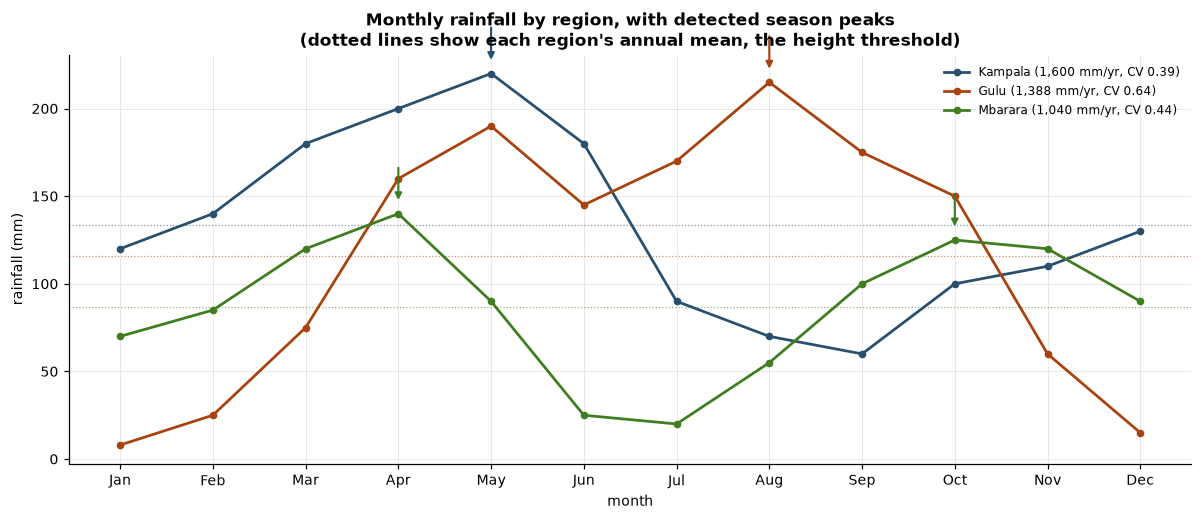

In [14]:
fig, ax = plt.subplots(figsize=(11, 4.8))
for index, region in enumerate(regions):
    ax.plot(MONTHS, region.rainfall, "o-", color=SERIES_COLOURS[index], lw=1.8,
            label=f"{region.name} ({region.annual:,.0f} mm/yr, CV {region.cv:.2f})")
    ax.axhline(region.monthly_mean, color=SERIES_COLOURS[index], lw=0.8, ls=":",
               alpha=0.6)
    for peak in detectors[region.name].indices():
        ax.annotate("", xy=(peak, region.rainfall[peak] + 6),
                    xytext=(peak, region.rainfall[peak] + 28),
                    arrowprops=dict(arrowstyle="-|>", color=SERIES_COLOURS[index],
                                    lw=1.4))
ax.set_xlabel("month")
ax.set_ylabel("rainfall (mm)")
ax.set_title("Monthly rainfall by region, with detected season peaks\n"
             "(dotted lines show each region's annual mean, the height threshold)")
ax.legend(fontsize=8)
fig.tight_layout()
print("saved:", store(fig, "p4_rainfall_lines.png").name)
plt.show()

saved: p4_suitability_heatmap.png


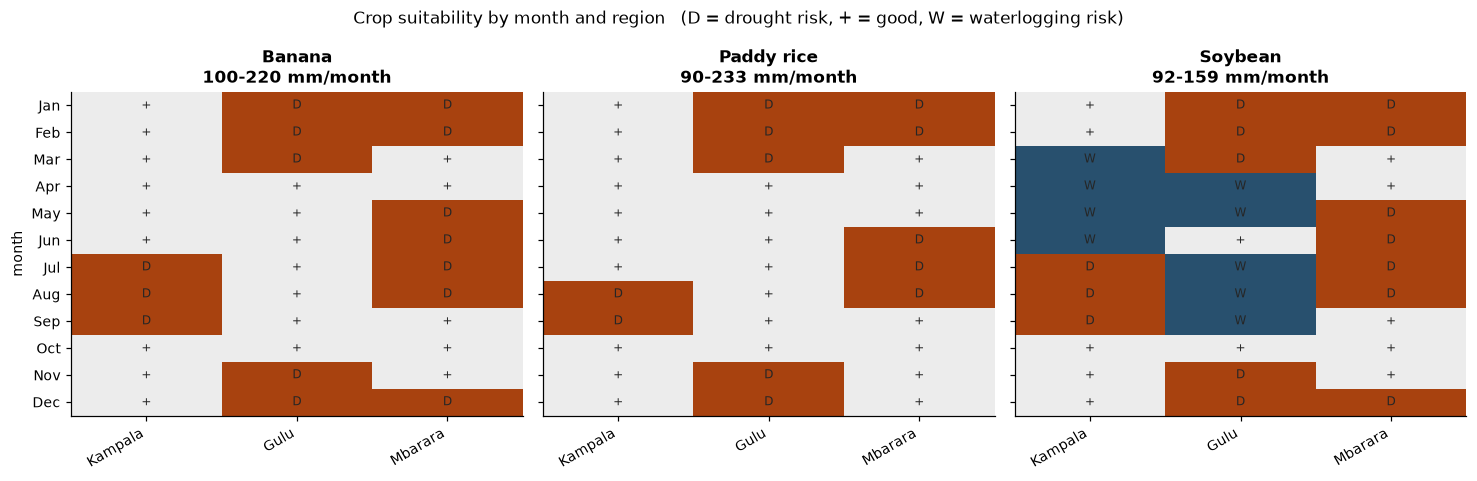

In [15]:
fig, axes = plt.subplots(1, len(CROPS), figsize=(13.5, 4.4), sharey=True)
palette = ListedColormap([SERIES_COLOURS[1], "#ececec", SERIES_COLOURS[0]])

for ax, rule in zip(axes, CROPS):
    codes = calendar.codes(rule.crop)
    ax.imshow(codes.to_numpy(), cmap=palette, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(regions)), [r.name for r in regions], rotation=30,
                  ha="right")
    ax.set_yticks(range(12), list(MONTHS))
    ax.set_title(f"{rule.crop}\n{rule.low:.0f}-{rule.high:.0f} mm/month")
    ax.grid(False)
    for row in range(12):
        for col in range(len(regions)):
            ax.text(col, row, {-1: "D", 0: "+", 1: "W"}[codes.iat[row, col]],
                    ha="center", va="center", fontsize=8, color="0.15")

axes[0].set_ylabel("month")
fig.suptitle("Crop suitability by month and region   "
             "(D = drought risk, + = good, W = waterlogging risk)", fontsize=11)
fig.tight_layout()
print("saved:", store(fig, "p4_suitability_heatmap.png").name)
plt.show()

## Task 7: advisory note for farmers around Kampala

*(Written for farmers and extension staff in the Kampala area, not for the
marker: plain language, named months, one clear recommendation.)*

In [16]:
for rule in CROPS:
    window = calendar.planting_window(rule.crop, "Kampala")
    print(f"{rule.crop:<12} suitable months in Kampala: "
          f"{', '.join(window) if window else 'none'}")
kampala = regions[0]
print(f"\nKampala: {kampala.annual:,.0f} mm/yr, wettest {kampala.wettest}, "
      f"driest {kampala.driest}, CV {kampala.cv:.2f}")

Banana       suitable months in Kampala: Jan, Feb, Mar, Apr, May, Jun, Oct, Nov, Dec
Paddy rice   suitable months in Kampala: Jan, Feb, Mar, Apr, May, Jun, Jul, Oct, Nov, Dec
Soybean      suitable months in Kampala: Jan, Feb, Oct, Nov, Dec

Kampala: 1,600 mm/yr, wettest May, driest Sep, CV 0.39


### Advisory note — Kampala area

Kampala receives about 1,600 mm of rain a year, more than Gulu or Mbarara,
and it is spread more evenly across the year than in either. Only three
months — July, August and September — fall below 100 mm, and even the driest,
September, still delivers 60 mm.

**Banana (matooke) is the crop this rainfall pattern suits best.** Nine of
the twelve months fall inside its 100–220 mm band, and because banana is a
perennial it benefits from exactly the thing that makes Kampala distinctive:
rain in most months rather than a single heavy season. A new plantation
established in **March or April** gets its roots down during the main rains
and is well enough developed to carry the July–September dry spell.

**Do not plant soybean in April or May.** Those months bring 200 mm and
220 mm, well above the 159 mm soybean tolerates, and the risk is root
disease and poor pod set rather than drought. If soybean is wanted, plant in
**October or November**, when rainfall of 100–130 mm sits comfortably inside
its band.

**July to September needs irrigation or a short-cycle crop.** Rainfall falls
to 60–90 mm, below what any of these three crops needs. Either plan a
supplementary watering, or use the window for a quick vegetable crop rather
than committing a full season.

One caution: these numbers are a single illustrative year, not a long-run
average. Check the current seasonal forecast from the Uganda National
Meteorological Authority before fixing a planting date, because year-to-year
variation can be larger than the differences discussed here.

## Extension: real rainfall data

The illustrative series describes one notional year. Real data shows how far
a given month varies *between* years, which is what actually decides whether
a planting date is safe. Download monthly precipitation from the
[NASA POWER Data Access Viewer](https://power.larc.nasa.gov/data-access-viewer/):
community *Agroclimatology*, temporal *Monthly & Annual*, parameter
*Precipitation Corrected (PRECTOTCORR)*, 2010-2023, CSV. Suggested points:
Kampala (0.35, 32.58), Gulu (2.78, 32.30), Mbarara (−0.61, 30.65). Save as
`data/nasa_power_Kampala.csv` and re-run.

The cell below uses whatever files exist and reports plainly if there are
none, so this notebook always runs top to bottom.

In [17]:
real = {}
for region in regions:
    candidate = DATA / f"nasa_power_{region.name}.csv"
    if candidate.exists():
        try:
            real[region.name] = load_power_csv(candidate)
        except ValueError as err:
            print(f"{candidate.name}: {err}")

if real:
    fig, axes = plt.subplots(1, len(real), figsize=(6 * len(real), 4.4),
                             sharey=True, squeeze=False)
    for ax, (name, table) in zip(axes[0], real.items()):
        ax.boxplot([table[m].to_numpy() for m in MONTHS], tick_labels=list(MONTHS))
        ax.set_title(f"{name} ({table.index.min()}-{table.index.max()})")
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylabel("rainfall (mm)")
    fig.suptitle("Year-to-year variability of monthly rainfall, NASA POWER",
                 fontsize=12)
    fig.tight_layout()
    print("saved:", store(fig, "p4_nasa_boxplots.png").name)
    plt.show()
else:
    print("No NASA POWER files in data/ — the extension is wired up but not run.")
    print("Download the CSVs named above and re-run to get the monthly box")
    print("plots. Nothing else in this notebook depends on them.")

No NASA POWER files in data/ — the extension is wired up but not run.
Download the CSVs named above and re-run to get the monthly box
plots. Nothing else in this notebook depends on them.


## Findings & Limitations

**Findings.** The three regions take comparable annual totals (1,040-1,600 mm)
and distribute them very differently, and the coefficient of variation
captures what the totals conceal: Gulu's 0.64 reflects one long season with a
near-dry January, against Kampala's 0.39. Cosine similarity, correctly
implemented and matching SciPy to machine precision, rates every pair of
regions between 0.75 and 0.89 — which reads as strong agreement and is in
fact an artefact of the data being non-negative, since all three vectors sit
in the positive orthant where cosine cannot fall below zero. Pearson
correlation, which centres first, shows the seasonal timing is essentially
unrelated (−0.17 to 0.21). Season detection using a height test at the annual
mean and a prominence test at one standard deviation classifies **Gulu as
unimodal and Mbarara as bimodal**, both matching documented climate zones,
and Mbarara's verdict holds from 0.25 to 2.0 standard deviations. Kampala is
called unimodal when it should be bimodal, but only because the illustrative
series omits the June-July dip. On crop suitability, all three crops need
roughly 90-100 mm a month at the lower bound despite seasonal requirements
differing by a factor of four, because crops with smaller seasonal needs also
have shorter growing periods; the classification is therefore driven by the
ceiling, and soybean's narrow 92-159 mm band is what restricts it to five
months in Kampala against banana's nine.

**Limitations.** The rainfall figures describe a single illustrative year, so
they carry no information about between-year variability — which is exactly
what determines whether a planting date is safe, and why the NASA POWER
extension matters. Monthly totals also hide the distribution within a month:
150 mm spread over twenty days and 150 mm in two are agronomically very
different, and only the second produces the waterlogging the classification
warns about. The crop bands divide FAO water needs by growing-period length,
which implicitly treats every month of a crop's cycle as equivalent; real
crops have critical stages, so a dry month at flowering costs far more than a
dry month at establishment. The bands take no account of soil type, drainage
or irrigation, so "waterlogging risk" is a statement about rainfall rather
than about any particular field. Finally, the detector has two tunable
parameters, and although the verdicts proved stable here, a region with a
genuinely marginal second season would sit on the boundary and its
classification would come down to the threshold rather than the climate.